<a href="https://colab.research.google.com/github/shravaniruikar/BML/blob/main/BML_exp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, silhouette_score

In [42]:
df = pd.read_csv("diabetes.csv")

In [48]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
5,5,116.0,74.0,29.0,125.0,25.6,0.201,30,0
7,10,115.0,72.0,29.0,125.0,35.3,0.134,29,0


In [49]:
invalid_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)
df[invalid_zero_cols] = df[invalid_zero_cols].fillna(df[invalid_zero_cols].median())


In [50]:
df = df.drop_duplicates()

In [51]:
def remove_outliers_strict(df, cols):
    mask = pd.Series(True, index=df.index)
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask &= df[col].between(lower, upper)
    return df[mask]

df = remove_outliers_strict(df, invalid_zero_cols)

In [52]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


In [53]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}

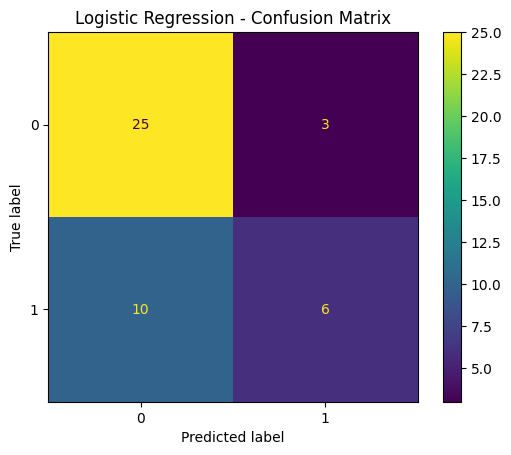

In [54]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
results['Logistic Regression'] = accuracy_score(y_test, y_pred_lr)
ConfusionMatrixDisplay.from_estimator(lr, X_test_scaled, y_test)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

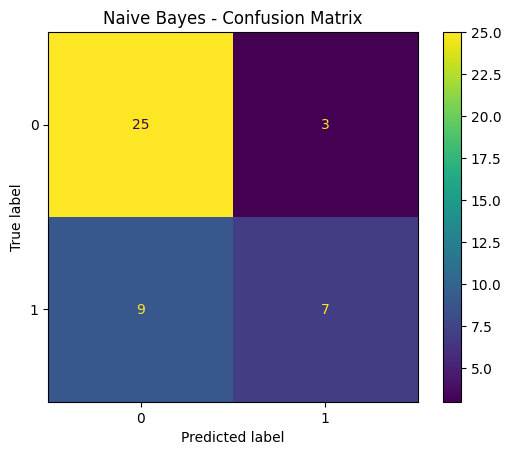

In [55]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)
results['Naive Bayes'] = accuracy_score(y_test, y_pred_nb)
ConfusionMatrixDisplay.from_estimator(nb, X_test_scaled, y_test)
plt.title("Naive Bayes - Confusion Matrix")
plt.show()


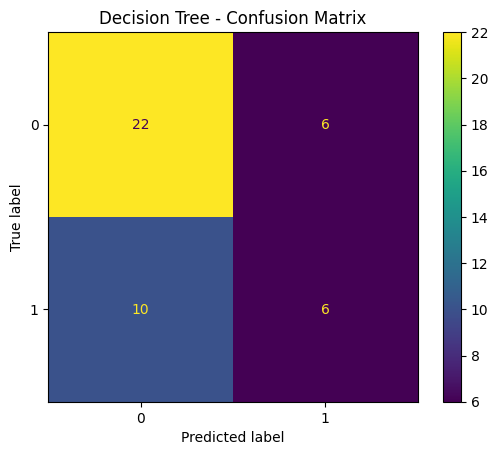

In [56]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
results['Decision Tree'] = accuracy_score(y_test, y_pred_dt)
ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test)
plt.title("Decision Tree - Confusion Matrix")
plt.show()

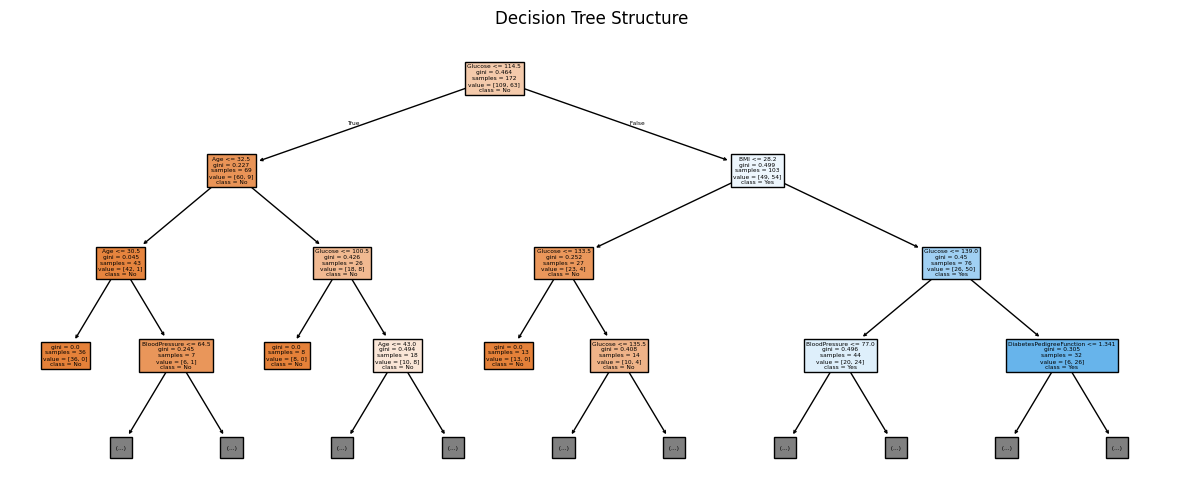

In [57]:
plt.figure(figsize=(15, 6))
plot_tree(dt, feature_names=X.columns, class_names=["No", "Yes"], filled=True, max_depth=3)
plt.title("Decision Tree Structure")
plt.show()

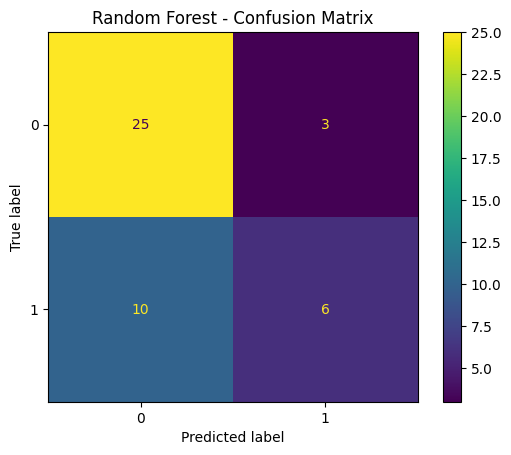

In [58]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results['Random Forest'] = accuracy_score(y_test, y_pred_rf)
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest - Confusion Matrix")
plt.show()

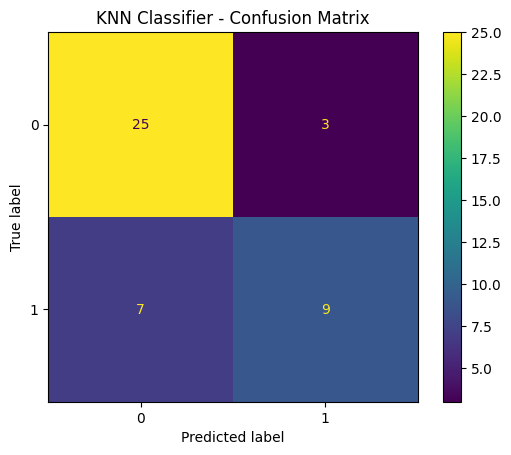

In [59]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
results['KNN Classifier'] = accuracy_score(y_test, y_pred_knn)
ConfusionMatrixDisplay.from_estimator(knn, X_test_scaled, y_test)
plt.title("KNN Classifier - Confusion Matrix")
plt.show()

In [60]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_train_scaled)
results['KMeans Clustering (Silhouette)'] = silhouette_score(X_train_scaled, kmeans_labels)


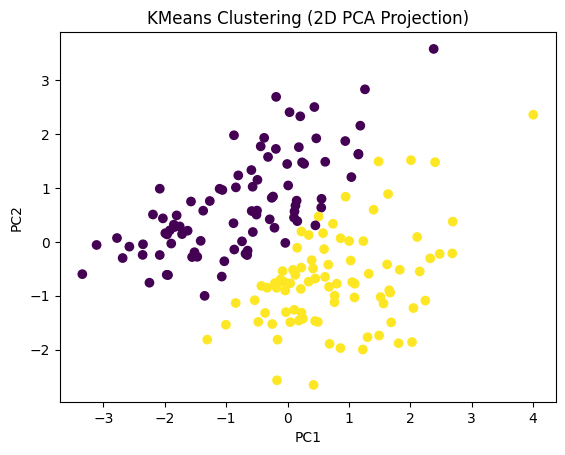

In [61]:
pca_kmeans = PCA(n_components=2)
X_pca_kmeans = pca_kmeans.fit_transform(X_train_scaled)
plt.scatter(X_pca_kmeans[:, 0], X_pca_kmeans[:, 1], c=kmeans_labels, cmap='viridis')
plt.title("KMeans Clustering (2D PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

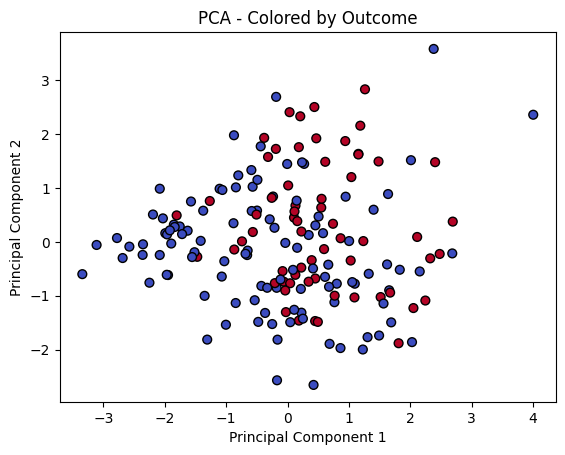

In [62]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='coolwarm', edgecolor='k', s=40)
plt.title("PCA - Colored by Outcome")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

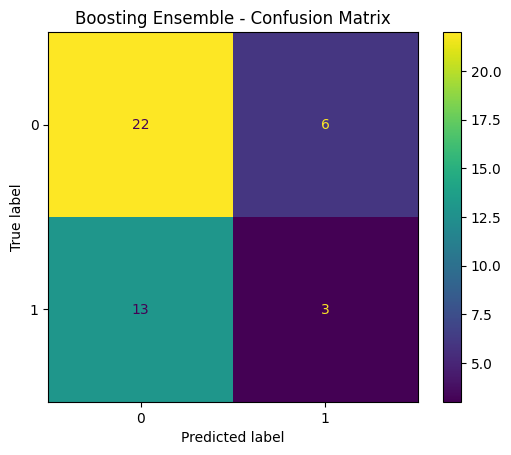

In [63]:
boost = GradientBoostingClassifier(random_state=42)
boost.fit(X_train, y_train)
y_pred_boost = boost.predict(X_test)
results['Boosting Ensemble'] = accuracy_score(y_test, y_pred_boost)
ConfusionMatrixDisplay.from_estimator(boost, X_test, y_test)
plt.title("Boosting Ensemble - Confusion Matrix")
plt.show()


In [64]:
print("\n🔍 Performance Summary:")
for model, score in results.items():
    print(f"{model}: {score:.4f}")


🔍 Performance Summary:
Logistic Regression: 0.7045
Naive Bayes: 0.7273
Decision Tree: 0.6364
Random Forest: 0.7045
KNN Classifier: 0.7727
KMeans Clustering (Silhouette): 0.1824
Boosting Ensemble: 0.5682
